<a href="https://colab.research.google.com/github/Himel738/AI-ML-Playground/blob/main/AI_ML/Machine_Learning/Week-01/Module-03/Machine_Learning_First_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Shohanur Rahman Shohan

E-mail: sohanurhimel@gmail.com

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

Q:1

In [33]:
titanic_data = pd.read_csv('Titanic-Dataset.csv')
print(titanic_data.shape)

print(titanic_data.head(10))

print(titanic_data.sample(5))

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J  

Q2:

In [34]:
print(titanic_data.isnull().sum())

duplicated_rows = titanic_data[titanic_data.duplicated()]
print(duplicated_rows)

titanic_data.drop_duplicates(inplace=True)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


Q:3

In [35]:
print(titanic_data.info())

print(titanic_data.describe())

# Found The Data Type and Null Values Ideas
# From Std How Data is fluctuating

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

Q:4

Axes(0.125,0.11;0.775x0.77)


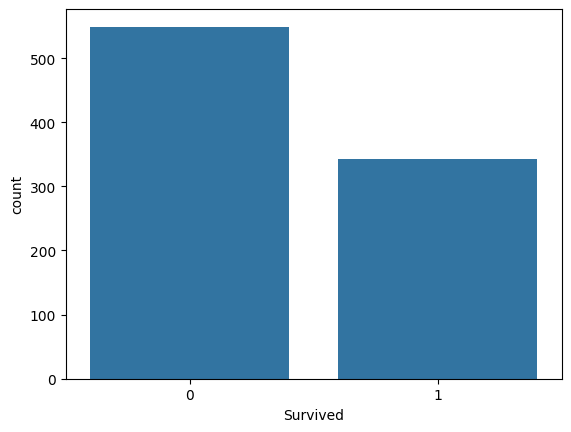

Survived
0    61.616162
1    38.383838
Name: count, dtype: float64


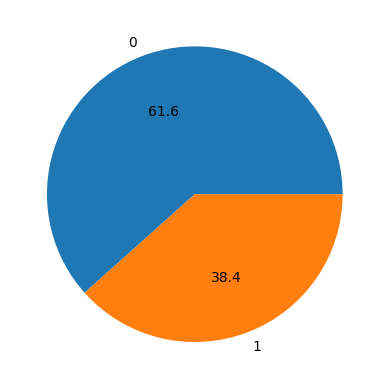

In [36]:
print(sns.countplot(data=titanic_data, x=titanic_data['Survived']))
plt.show()
print((titanic_data['Survived'].value_counts()/len(titanic_data)) * 100)

plt.pie(titanic_data['Survived'].value_counts(),
        labels=titanic_data['Survived'].unique(),
        autopct="%1.1f"
        )
plt.show()

Q:5

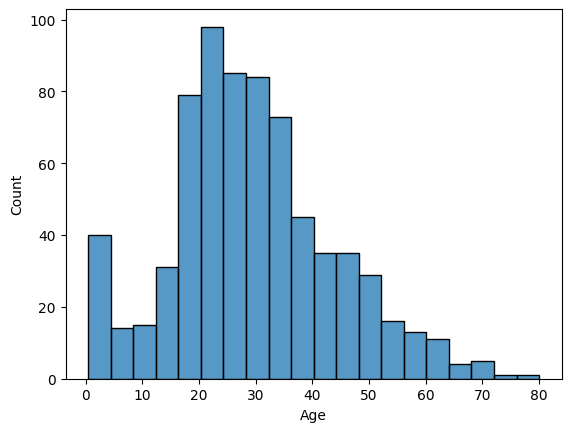

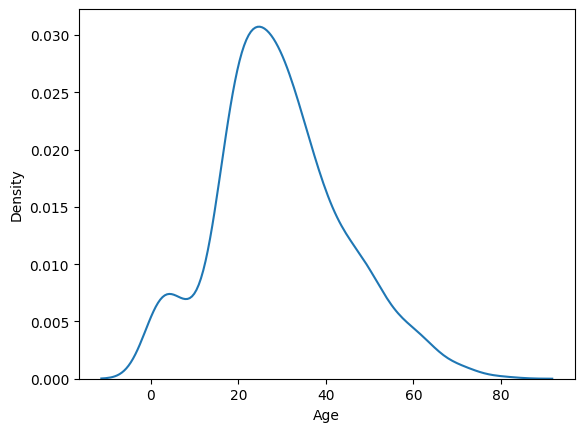

In [37]:
sns.histplot(data=titanic_data,x=titanic_data['Age'])
plt.show()
sns.kdeplot(data=titanic_data,x=titanic_data['Age'])
plt.show()

# Maximum Member is Between 20 to 40
# Right Skewed

Q6:

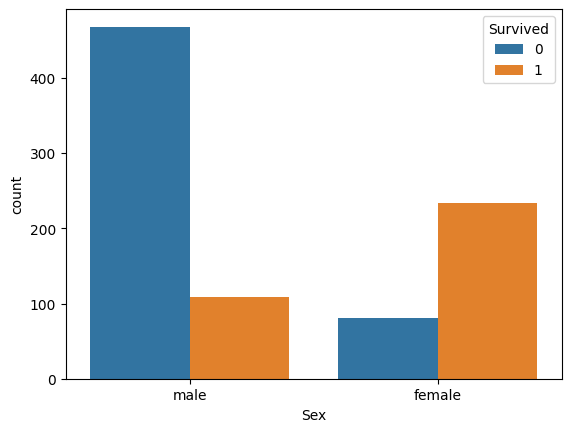

Sex     Survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64


In [38]:
sns.countplot(data=titanic_data,x=titanic_data['Sex']
              ,hue=titanic_data['Survived'])
plt.show()

gender_split = titanic_data.groupby('Sex')['Survived'].value_counts(normalize=True)
print(gender_split)

# How Many Survived and Not From Male And Female(Survived Rate is Higher)
# Male Survived Rate is Lower

Q:7

<Axes: xlabel='Pclass', ylabel='Fare'>

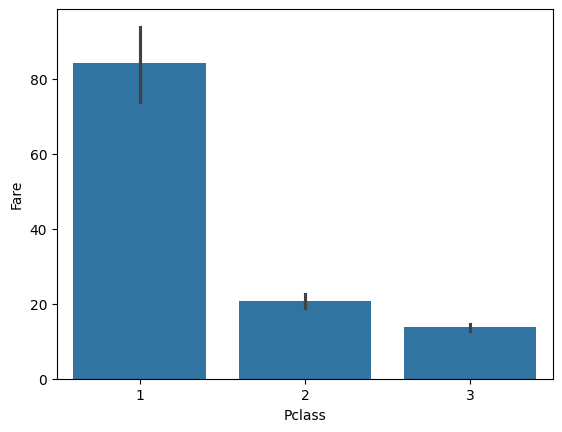

In [39]:
sns.barplot(x=titanic_data['Pclass'],
            y=titanic_data['Fare'])
# The Average Fare of Class is SHowing
# Error Class Shows Variability larger in first Class

Q:**8**

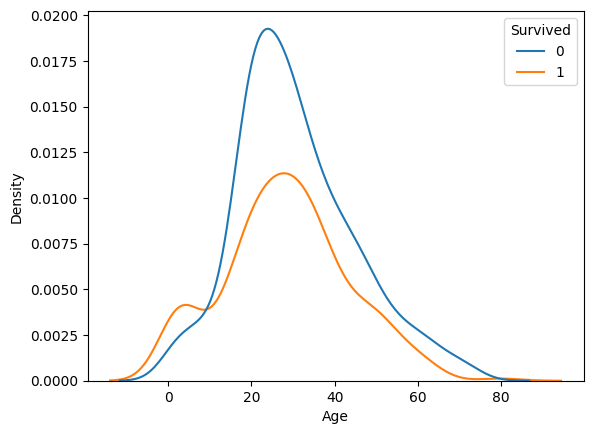

In [40]:
sns.kdeplot(data=titanic_data,x=titanic_data['Age'],
            hue=titanic_data['Survived'])
plt.show()

# Children had Higher Survival Rate
# Most Passenger are Young both Survived peak near  this range 20-40

Q:9

In [ ]:
titanic_data.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [47]:

X = titanic_data.drop(['Survived'],axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,NaN,S
887,1,female,19.0,0,0,30.0000,B42,S
888,3,female,NaN,1,2,23.4500,NaN,S
889,1,male,26.0,0,0,30.0000,C148,C


In [48]:
y = titanic_data['Survived']
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [50]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
print(X_train.shape)
print(X_test.shape)

(712, 8)
(179, 8)


Q:10

In [51]:
from sklearn.impute import SimpleImputer

In [56]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
age_imputer.fit(X_train[['Age']])
X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()

In [61]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
embarked_imputer.fit(X_train[['Embarked']])
X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()

In [65]:
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy='constant',fill_value='Missing',add_indicator=True)
cabin_imputer.fit(X_train[['Cabin']])
X_train[['Cabin','cabin_indicator']] = cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin','cabin_indicator']] = cabin_imputer.transform(X_test[['Cabin']])

In [67]:
X_train.isnull().sum()
X_test.isnull().sum()
y_train.isnull().sum()
y_test.isnull().sum()

np.int64(0)